## MLP-AE: CM_ROC All Homes - sim & real

10/10 [==============================] - 0s 1ms/step
Threshold saved at: 0.01806561017243623
Anomalous Data Indices:
[  9  22  28  30  37  40  42  57  62  72  73  74  77  85  86  91  95 102
 107 115 131 137 145 159 172 174 177 187 190 193 200 228 229 237 248 255
 256 266 269 286 289]
Confusion Matrix:
 [[137   9]
 [112  32]]
Accuracy: 0.5827586206896552
Precision: 0.7804878048780488
Recall: 0.2222222222222222
TNR: 0.9383561643835616
FPR: 0.06164383561643835
FNR: 0.7777777777777778
F1 Score: 0.34594594594594597
ROC AUC: 0.7478595890410961


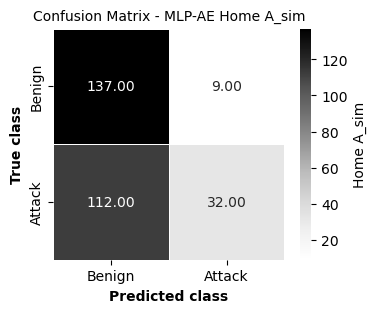

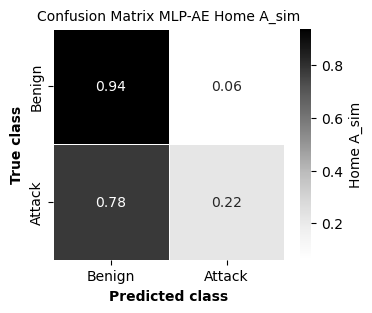

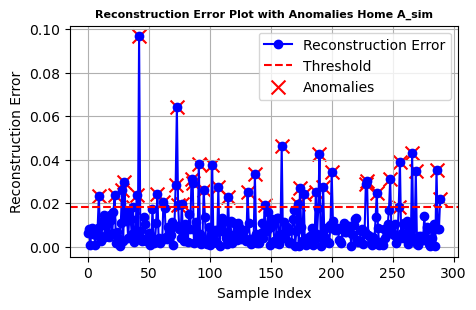

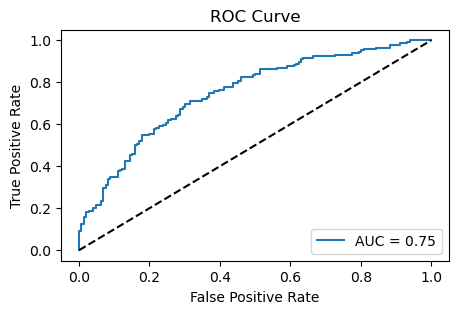

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns


def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
#     conf_matrix = confusion_matrix(y_test, anomalies)
    
    # Calculate and print the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

 #########################################################
    # Original confusion matrix
    array = [[137, 9],
             [112, 32]]

    plt.rcParams.update({'font.size': 10})
    df_cm = pd.DataFrame(array, range(2), range(2))
    # LABELS = ['Benign', 'DoS']
    LABELS = ['Benign', 'Attack']
    plt.figure(figsize=(4, 3))
    sns.heatmap(df_cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="0.2f",annot_kws={"size": 10}, 
               linewidths=0.5, square=True, cbar_kws={'label': 'Home A_sim'}, cmap=plt.cm.Greys) # font size
    # sn.heatmap(df_cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",annot_kws={"size": 12}, cmap=plt.cm.Blues) # font size
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap=model_info['cmap'], linewidths=0.5, square=True, cbar_kws={'label': 'Home A'})
    # plt.title("Confusion Matrix - DoS")
    plt.title("Confusion Matrix - MLP-AE Home A_sim", fontsize=10)
    plt.ylabel('True class',fontsize=10, fontweight='bold')
    plt.xlabel('Predicted class',fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_MLP-AE_sim_r.png', bbox_inches='tight')
    
####################################################

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)

    # Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home A_sim'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted class',fontsize=10, fontweight='bold')
    plt.ylabel('True class',fontsize=10, fontweight='bold')
    plt.title('Confusion Matrix MLP-AE Home A_sim', fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_MLP-AE_sim_n.png',bbox_inches='tight')
    # plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
    plt.show()


    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

    # Highlight anomalous points with unique color and marker
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')

    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home A_sim', fontsize=8, fontweight='bold')
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_MLP-AE.png', bbox_inches='tight')
    plt.show()


    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


548/548 [==============================] - 1s 1ms/step
Threshold saved at: 0.01806561017243623
Anomalous Data Indices:
[   18    92    98 ... 17499 17510 17519]
Confusion Matrix:
 [[8321  439]
 [8192  568]]
Accuracy: 0.5073630136986301
Precision: 0.564051638530288
Recall: 0.06484018264840183
TNR: 0.9498858447488584
FPR: 0.05011415525114155
FNR: 0.9351598173515981
F1 Score: 0.11631002354868435
ROC AUC: 0.5798235806175851


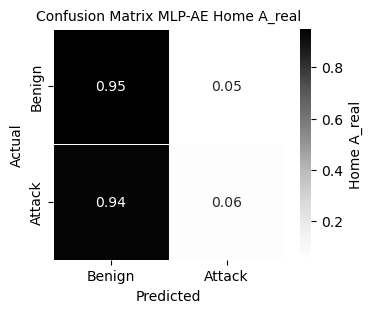

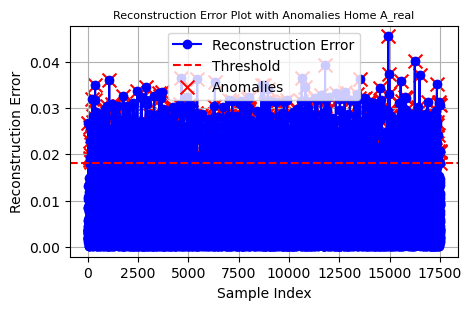

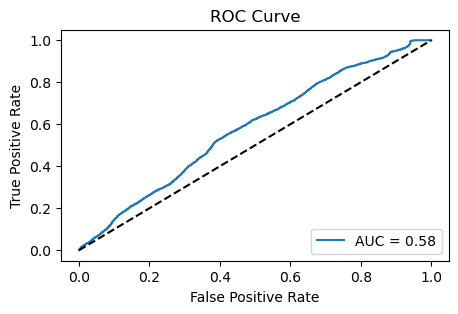

In [2]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

# import seaborn as sns

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)

    # Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home A_real'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix MLP-AE Home A_real', fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_MLP-AE_real.png',bbox_inches='tight')
    # plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
    plt.show()


    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

    # Highlight anomalous points with unique color and marker
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')

    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home A_real', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_MLP-AE.png', bbox_inches='tight')
    plt.show()


    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


9/9 [==============================] - 0s 1ms/step
Threshold saved at: 0.01806561017243623
Anomalous Data Indices:
[  0   2   3   4   6   7  10  12  13  20  21  26  28  29  33  34  35  36
  37  38  39  40  43  44  45  46  47  48  50  54  55  57  66  70  74  77
  78  79  80  81  82  85  91  92  96  97  98  99 101 107 108 110 111 114
 116 117 123 125 128 132 135 145 150 151 152 153 154 155 158 161 162 167
 170 171 173 174 175 176 178 182 185 187 189 190 191 192 195 196 198 199
 202 204 205 207 208 211 212 214 220 225 226 233 234 237 243 248 249 250
 251 253 260 268 270 273 274 275 277 278 279 280 281 282 286]
Confusion Matrix:
 [[109  37]
 [ 56  86]]
Accuracy: 0.6770833333333334
Precision: 0.6991869918699187
Recall: 0.6056338028169014
TNR: 0.7465753424657534
FPR: 0.2534246575342466
FNR: 0.39436619718309857
F1 Score: 0.6490566037735849
ROC AUC: 0.7528458421763456


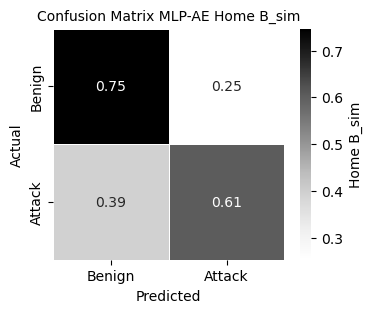

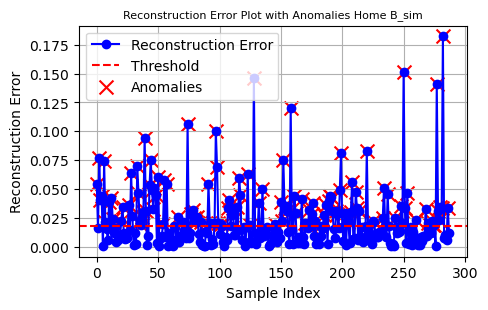

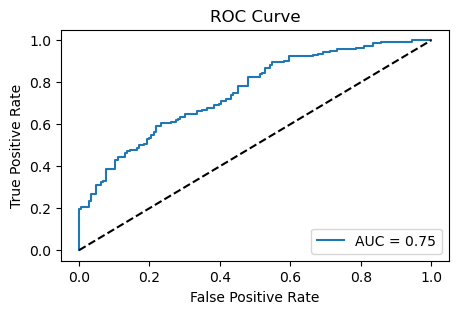

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

# import seaborn as sns

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)

    # Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home B_sim'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix MLP-AE Home B_sim', fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_MLP-AE_sim.png',bbox_inches='tight')
    # plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
    plt.show()


    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

    # Highlight anomalous points with unique color and marker
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')

    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home B_sim', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_MLP-AE.png', bbox_inches='tight')
    plt.show()


    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


548/548 [==============================] - 1s 935us/step
Threshold saved at: 0.01806561017243623
Anomalous Data Indices:
[    0     8     9 ... 17513 17516 17519]
Confusion Matrix:
 [[6120 2640]
 [4967 3793]]
Accuracy: 0.565810502283105
Precision: 0.5896160422819835
Recall: 0.4329908675799087
TNR: 0.6986301369863014
FPR: 0.3013698630136986
FNR: 0.5670091324200913
F1 Score: 0.4993088922530113
ROC AUC: 0.6228275317445425


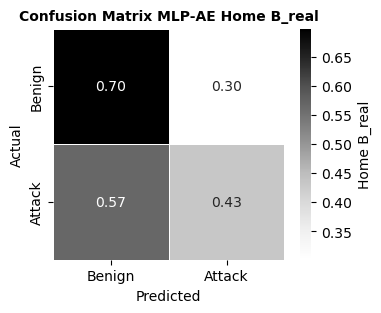

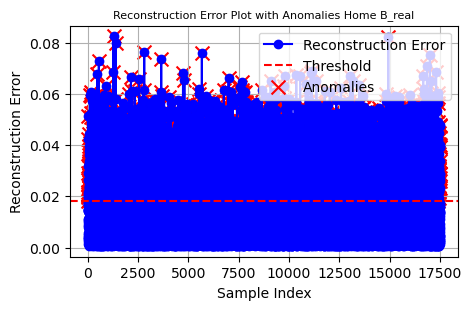

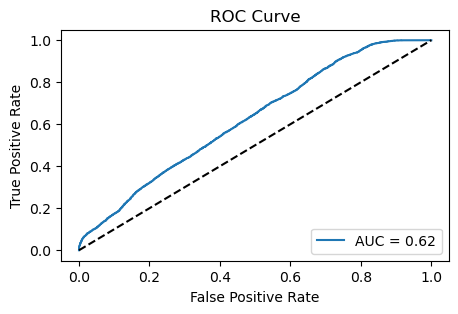

In [4]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

# import seaborn as sns

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)

    # Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home B_real'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix MLP-AE Home B_real', fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_MLP-AE_real.png',bbox_inches='tight')
    # plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
    plt.show()


    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

    # Highlight anomalous points with unique color and marker
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')

    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home B_real', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_MLP-AE.png', bbox_inches='tight')
    plt.show()


    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


9/9 [==============================] - 0s 1ms/step
Threshold saved at: 0.01806561017243623
Anomalous Data Indices:
[ 15  66  90 150 163 197 237 240 269]
Confusion Matrix:
 [[144   2]
 [126   7]]
Accuracy: 0.5412186379928315
Precision: 0.7777777777777778
Recall: 0.05263157894736842
TNR: 0.9863013698630136
FPR: 0.0136986301369863
FNR: 0.9473684210526315
F1 Score: 0.09859154929577464
ROC AUC: 0.7500772479143062


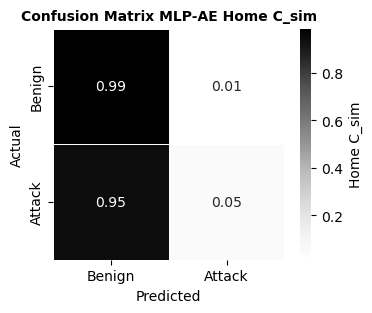

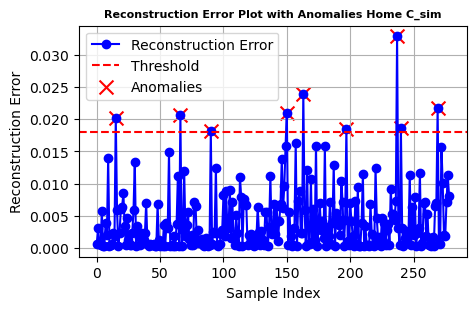

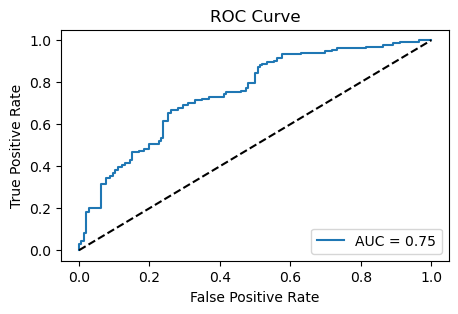

In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

# import seaborn as sns

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)

    # Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home C_sim'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix MLP-AE Home C_sim', fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_MLP-AE_sim.png',bbox_inches='tight')
    # plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
    plt.show()


    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

    # Highlight anomalous points with unique color and marker
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')

    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home C_sim', fontsize=8, fontweight='bold')
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_MLP-AE.png', bbox_inches='tight')
    plt.show()


    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
if __name__ == "__main__":
    main()


548/548 [==============================] - 1s 910us/step
Threshold saved at: 0.01806561017243623
Anomalous Data Indices:
[  226   475   477   553   693   893   896  1066  1227  1404  1521  1709
  2106  2610  2692  2899  2981  3021  3105  3147  3351  3448  3565  3796
  3837  3896  4107  4322  4627  4662  4831  4854  4931  4937  4961  5027
  5031  5069  5110  5113  5261  5331  5437  5730  5812  5843  5910  5944
  5953  5966  6140  6264  6335  6367  6414  6477  7086  7355  7433  7442
  7787  7947  7985  8160  8451  8493  8637  8891  8913  8931  9079  9197
  9550  9656  9689  9747  9776 10022 10062 10496 10590 10694 10936 10996
 11559 11748 12067 12114 12142 12200 12479 12885 13146 13253 13343 13555
 13630 13698 13910 13934 14009 14546 14670 14693 14747 14958 15053 15196
 15608 15624 15731 16098 16293 16367 16726 16790 17027 17459]
Confusion Matrix:
 [[8723   37]
 [8679   81]]
Accuracy: 0.5025114155251141
Precision: 0.6864406779661016
Recall: 0.009246575342465754
TNR: 0.9957762557077625
FP

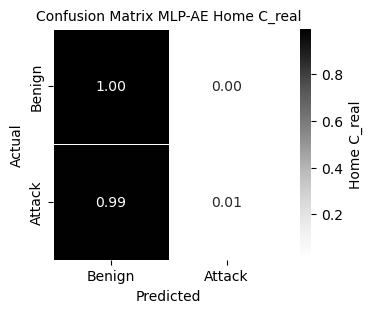

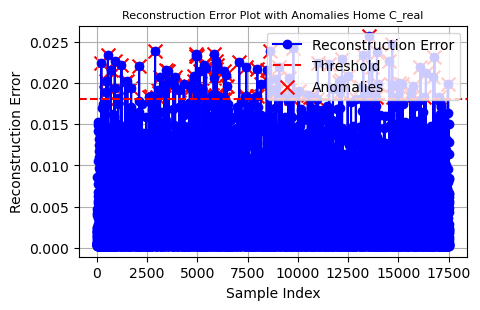

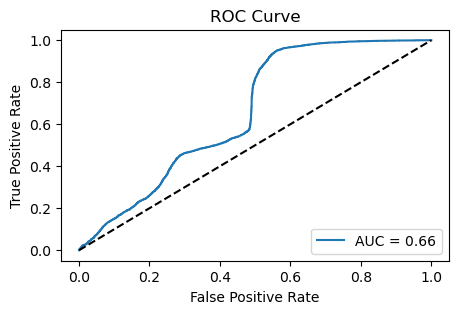

In [6]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

# import seaborn as sns

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)

    # Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home C_real'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix MLP-AE Home C_real', fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_MLP-AE_real.png',bbox_inches='tight')
    # plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
    plt.show()


    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

    # Highlight anomalous points with unique color and marker
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')

    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home C_real', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_MLP-AE.png', bbox_inches='tight')
    plt.show()


    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


## 1D-CONV-AE: CM_ROC - All Homes - sim & real

10/10 [==============================] - 0s 13ms/step
Threshold saved at: 0.0004384780379249808
Anomalous Data Indices:
[ 30  42  57  73  77  86  95 120 137 150 155 159 174 184 256 260 266 269]
Confusion Matrix:
 [[145   1]
 [127  17]]
Accuracy: 0.5586206896551724
Precision: 0.9444444444444444
Recall: 0.11805555555555555
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.8819444444444444
F1 Score: 0.20987654320987653
ROC AUC: 0.6968226788432268


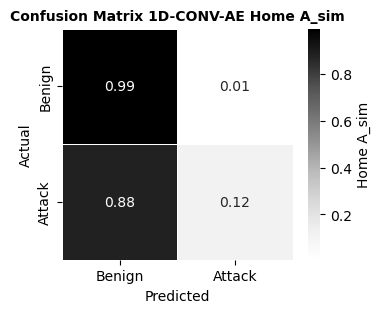

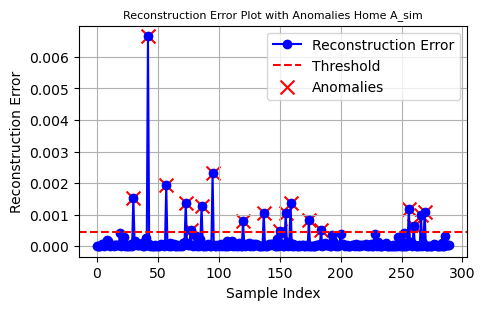

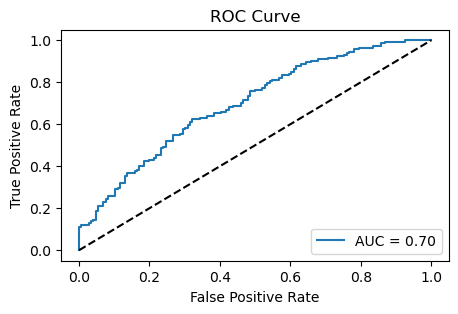

In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_1D-autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return
    
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_1D-threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

    # Calculate the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home A_sim'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix 1D-CONV-AE Home A_sim', fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_1D-CONV-AE_sim.png',bbox_inches='tight')
    plt.show()

    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home A_sim', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_1D-CONV-AE.png', bbox_inches='tight')
    plt.show()

    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


548/548 [==============================] - 8s 14ms/step
Threshold saved at: 0.0004384780379249808
Anomalous Data Indices:
[   75   115   170   450   881  1204  1711  1845  1878  1971  2096  2309
  2754  2777  3111  3135  3380  4024  4087  4144  4182  4396  4931  4953
  5114  5133  5402  5539  5668  5785  5791  5898  6202  6209  6421  6865
  6879  6921  6978  7179  7296  7355  7437  7551  7682  7787  7933  8052
  8063  8084  8388  8616  8751  8808  8885  8962  9001  9052  9370  9566
  9605  9792 10184 10297 10401 10424 10430 10782 10936 11125 11185 11324
 11366 11395 11759 11959 12114 12489 12733 12880 12979 13173 13174 13210
 13320 13472 13515 13674 13754 13885 13923 14011 14081 14222 14566 14708
 14939 15042 15137 15156 15293 15348 15459 15726 15998 16079 16134 16168
 16391 16615 16697 16762 16921 17017 17244 17445 17459 17500]
Confusion Matrix:
 [[8730   30]
 [8672   88]]
Accuracy: 0.503310502283105
Precision: 0.7457627118644068
Recall: 0.01004566210045662
TNR: 0.9965753424657534
FPR

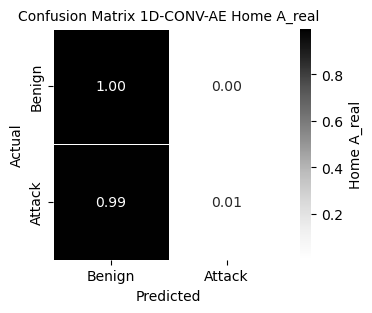

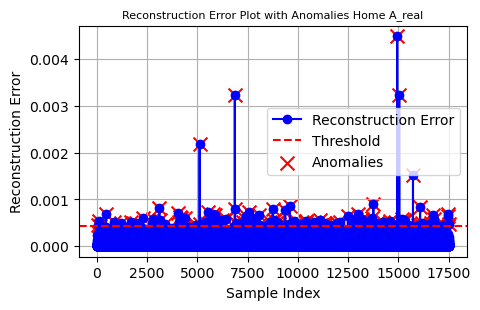

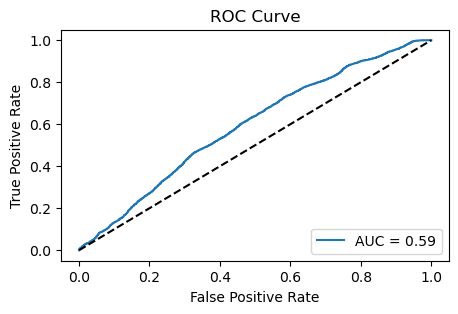

In [10]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_1D-autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return
    
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_1D-threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

    # Calculate the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home A_real'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix 1D-CONV-AE Home A_real', fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_1D-CONV-AE_real.png',bbox_inches='tight')
    plt.show()

    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home A_real', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LUM_1D-CONV-AE.png', bbox_inches='tight')
    plt.show()

    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


9/9 [==============================] - 0s 14ms/step
Threshold saved at: 0.0004384780379249808
Anomalous Data Indices:
[  0   2   6  10  27  28  33  39  44  45  50  55  74  77  91  97  98 107
 128 144 150 152 158 190 191 199 212 214 249 250 277 282]
Confusion Matrix:
 [[145   1]
 [111  31]]
Accuracy: 0.6111111111111112
Precision: 0.96875
Recall: 0.21830985915492956
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.7816901408450704
F1 Score: 0.3563218390804597
ROC AUC: 0.7829442407871888


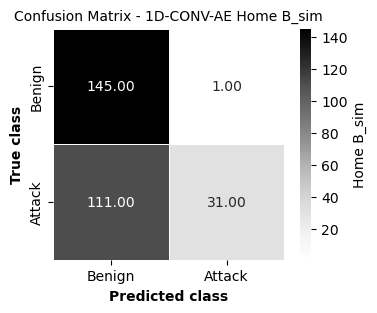

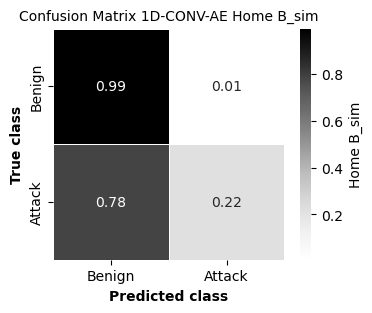

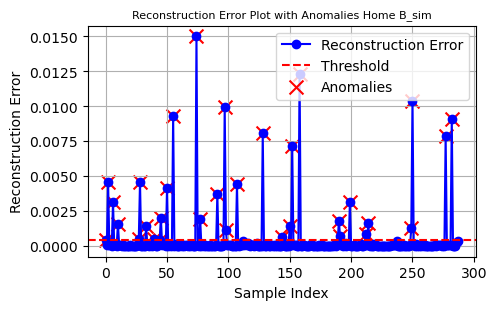

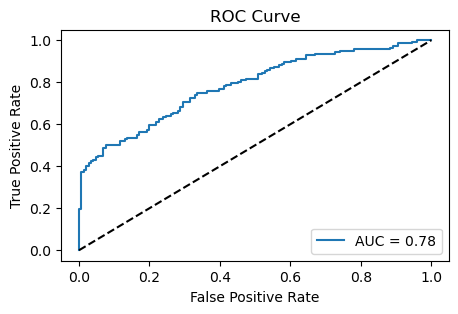

In [12]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_1D-autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return
    
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_1D-threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
#     conf_matrix = confusion_matrix(y_test, anomalies)
    
    # Calculate and print the confusion matrix
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)
    
    ########################################
    # Original confusion matrix
    array = [[145, 1],
             [111, 31]]

    plt.rcParams.update({'font.size': 10})
    df_cm = pd.DataFrame(array, range(2), range(2))
    # LABELS = ['Benign', 'DoS']
    LABELS = ['Benign', 'Attack']
    plt.figure(figsize=(4, 3))
    sns.heatmap(df_cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="0.2f",annot_kws={"size": 10}, 
               linewidths=0.5, square=True, cbar_kws={'label': 'Home B_sim'}, cmap=plt.cm.Greys) # font size
    # sn.heatmap(df_cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",annot_kws={"size": 12}, cmap=plt.cm.Blues) # font size
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap=model_info['cmap'], linewidths=0.5, square=True, cbar_kws={'label': 'Home A'})
    # plt.title("Confusion Matrix - DoS")
    plt.title("Confusion Matrix - 1D-CONV-AE Home B_sim", fontsize=10)
    plt.ylabel('True class',fontsize=10, fontweight='bold')
    plt.xlabel('Predicted class',fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_1D-CONV-AE_sim_r.png', bbox_inches='tight')
    
    
    ########################################

    # Calculate the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home B_sim'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted class',fontsize=10, fontweight='bold')
    plt.ylabel('True class',fontsize=10, fontweight='bold')
    plt.title('Confusion Matrix 1D-CONV-AE Home B_sim', fontsize=10)
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_1D-CONV-AE_sim_n.png',bbox_inches='tight')
    plt.show()

    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home B_sim', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_1D-CONV-AE.png', bbox_inches='tight')
    plt.show()

    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


548/548 [==============================] - 14s 24ms/step
Threshold saved at: 0.0004384780379249808
Anomalous Data Indices:
[  168   224   252   274   490   723   744   878   975  1071  1167  1323
  1344  1391  1523  1770  1888  2214  2624  2769  2801  2981  3093  3174
  3204  3294  3302  3628  3646  3666  3990  4100  4109  4150  4226  4343
  4386  4612  4797  4818  4852  4949  5114  5668  5810  5813  5838  5891
  5904  5949  6000  6315  6526  6680  6761  6833  6865  6970  7297  7361
  7363  7652  7662  8103  8201  8219  8275  8509  8627  8943  9049  9082
  9185  9193  9217  9424  9436  9463  9670  9825  9847  9927 10007 10170
 10187 10387 10483 10598 10606 10630 10793 10836 10843 10863 11091 11137
 11217 11267 11537 11555 11807 11876 12034 12411 12463 12520 12840 12917
 12989 13042 13160 13171 13313 13435 13542 13622 13625 13653 13750 13754
 13763 13806 14203 14310 14374 14423 14631 14802 14807 14939 15042 15219
 15329 15651 15726 15738 15743 15798 15835 16168 16280 16587 16769 16861
 

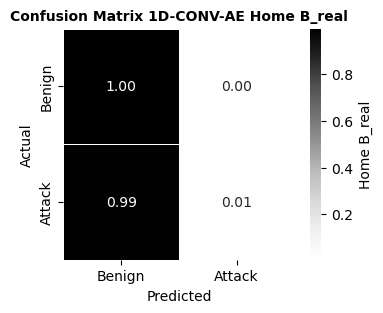

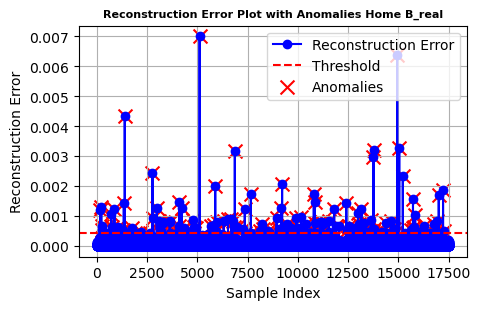

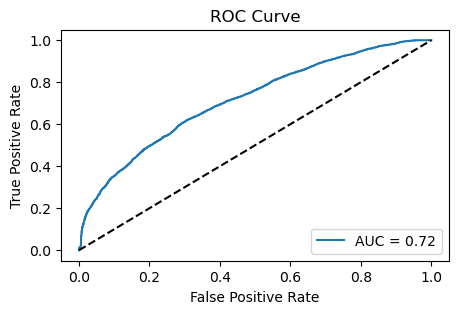

In [21]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_1D-autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return
    
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_1D-threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)
    ########################################
    # Original confusion matrix
    array = [[145, 1],
             [111, 31]]

    plt.rcParams.update({'font.size': 10})
    df_cm = pd.DataFrame(array, range(2), range(2))
    # LABELS = ['Benign', 'DoS']
    LABELS = ['Benign', 'Attack']
    plt.figure(figsize=(4, 3))
    sns.heatmap(df_cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="0.2f",annot_kws={"size": 10}, 
               linewidths=0.5, square=True, cbar_kws={'label': 'Home B_real'}, cmap=plt.cm.Greys) # font size
    # sn.heatmap(df_cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",annot_kws={"size": 12}, cmap=plt.cm.Blues) # font size
    # sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap=model_info['cmap'], linewidths=0.5, square=True, cbar_kws={'label': 'Home A'})
    # plt.title("Confusion Matrix - DoS")
    plt.title("Confusion Matrix - 1D-CONV-AE Home B_real", fontsize=10)
    plt.ylabel('True class',fontsize=10, fontweight='bold')
    plt.xlabel('Predicted class',fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_1D-CONV-AE_real_r.png', bbox_inches='tight')
    
    
    ########################################

    # Calculate the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home B_real'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix 1D-CONV-AE Home B_real', fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_1D-CONV-AE_real.png',bbox_inches='tight')
    plt.show()

    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home B_real', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B_up\LUM_1D-CONV-AE.png', bbox_inches='tight')
    plt.show()

    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


9/9 [==============================] - 1s 37ms/step
Threshold saved at: 0.0004384780379249808
Anomalous Data Indices:
[ 15  69 102 134 163 247 272]
Accuracy: 0.5412186379928315
Precision: 0.8571428571428571
Recall: 0.045112781954887216
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.9548872180451128
F1 Score: 0.0857142857142857
ROC AUC: 0.7142342156761767


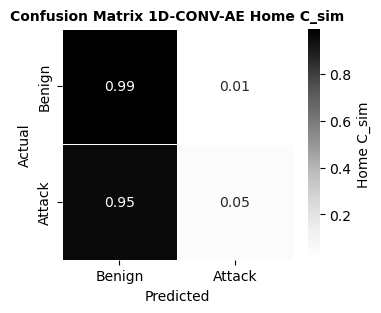

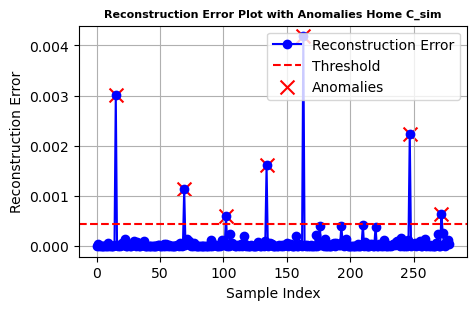

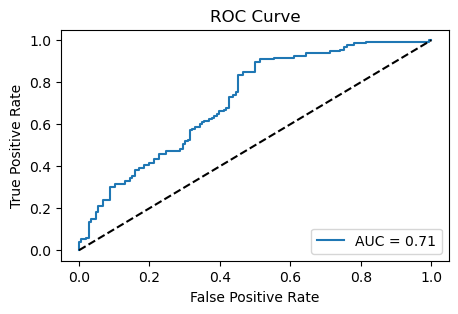

In [22]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_1D-autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return
    
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_1D-threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

    # Calculate the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home C_sim'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix 1D-CONV-AE Home C_sim', fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_1D-CONV-AE_sim.png',bbox_inches='tight')
    plt.show()

    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home C_sim', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_1D-CONV-AE.png', bbox_inches='tight')
    plt.show()

    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


548/548 [==============================] - 18s 33ms/step
Threshold saved at: 0.0004384780379249808
Anomalous Data Indices:
[   75   170   644   881   934  1056  1148  1792  1878  1920  1971  2055
  2235  2281  2608  2981  3072  3159  3189  3380  3443  3449  4087  4182
  4229  4256  4322  4328  4396  4598  4831  4931  4953  5114  5115  5130
  5175  5583  5668  5713  5785  5944  6082  6525  6575  6767  6970  6978
  7355  7534  7573  7719  7933  7947  8808  9157  9200  9511  9566  9730
  9792  9861  9890 10252 10447 10782 10785 10936 11125 11366 11395 11486
 11559 11583 12114 12190 12200 12716 13055 13174 13326 13329 13370 13387
 13472 13515 13580 13885 14079 14222 14243 14537 14708 14796 15167 15397
 15998 16242 16438 16596 16615 16857 17011 17080 17244 17278 17358 17459
 17500]
Accuracy: 0.5017694063926941
Precision: 0.6422018348623854
Recall: 0.007990867579908675
TNR: 0.9955479452054794
FPR: 0.004452054794520548
FNR: 0.9920091324200914
F1 Score: 0.015785319652722965
ROC AUC: 0.65877426

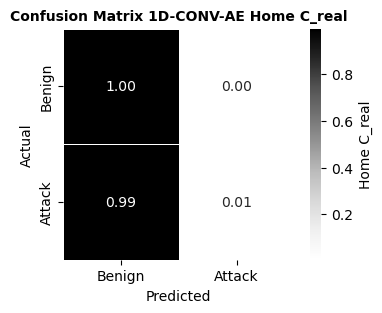

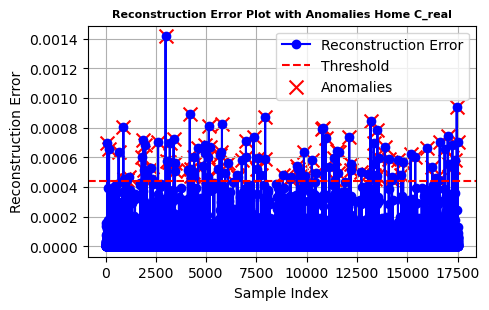

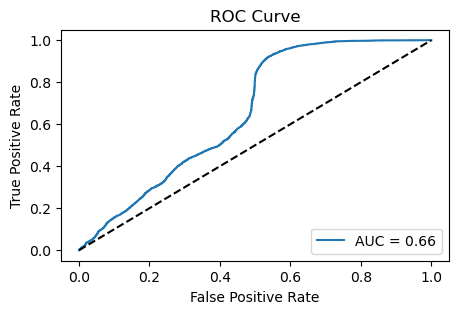

In [24]:
def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_1D-autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return
    
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load("trained_1D-threshold.npy")
    print("Threshold saved at:", threshold)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Print the indices of anomalous data
    print("Anomalous Data Indices:")
    anomalous_indices = np.where(anomalies)[0]
    print(anomalous_indices)

    # Evaluate performance metrics
    accuracy = accuracy_score(y_test, anomalies)
    precision = precision_score(y_test, anomalies)
    recall = recall_score(y_test, anomalies)
    conf_matrix = confusion_matrix(y_test, anomalies)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
    tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
    fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

    f1 = f1_score(y_test, anomalies)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)
    fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

    # Print performance metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("TNR:", tnr)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

    # Calculate the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
                cbar_kws={'label': 'Home C_real'},
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix 1D-CONV-AE Home C_real', fontsize=10, fontweight='bold')
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_1D-CONV-AE_real.png',bbox_inches='tight')
    plt.show()

    # Plot reconstruction error with anomalous points highlighted
    plt.figure(figsize=(5, 3))
    plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
                color='red', marker='x', s=100, label='Anomalies')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error Plot with Anomalies Home C_real', fontsize=8)
    plt.legend()
    plt.grid()
    plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LUM_1D-CONV-AE.png', bbox_inches='tight')
    plt.show()

    # Plot ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Rest of the code...

if __name__ == "__main__":
    main()


9/9 [==============================] - 0s 2ms/step
Mean Absolute Error: 0.08839371335614368
Mean Squared Error: 0.023032220512942413


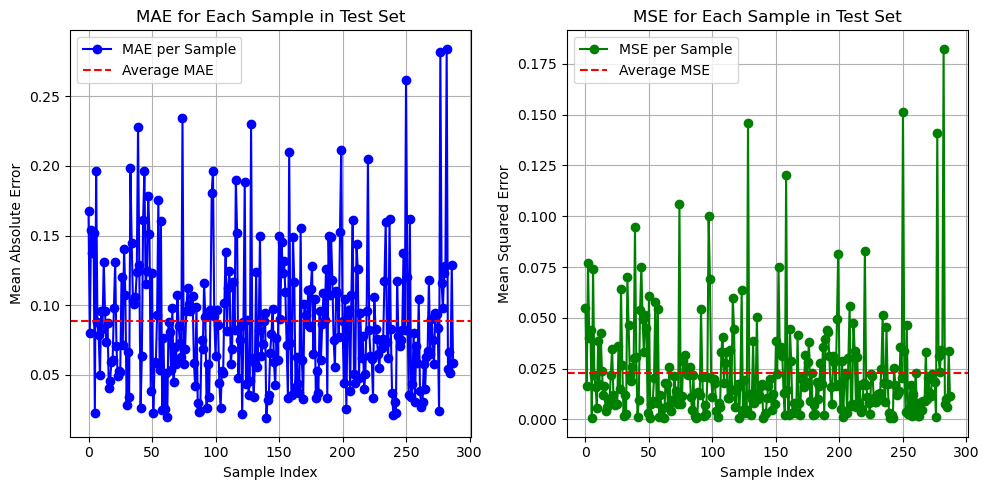

In [26]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    # Calculate MAE and MSE
    mae = mean_absolute_error(X_test_scaled, test_predictions)
    mse = mean_squared_error(X_test_scaled, test_predictions)
    print("Mean Absolute Error:", mae)
    print("Mean Squared Error:", mse)

    # Calculate element-wise MAE and MSE for visualization
    mae_per_sample = np.mean(np.abs(X_test_scaled - test_predictions), axis=1)
    mse_per_sample = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Plotting MAE and MSE
    plt.figure(figsize=(10, 5))

    # Plot MAE
    plt.subplot(1, 2, 1)
    plt.plot(mae_per_sample, marker='o', linestyle='-', color='b', label='MAE per Sample')
    plt.axhline(y=mae, color='r', linestyle='--', label='Average MAE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Absolute Error')
    plt.title('MAE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    # Plot MSE
    plt.subplot(1, 2, 2)
    plt.plot(mse_per_sample, marker='o', linestyle='-', color='g', label='MSE per Sample')
    plt.axhline(y=mse, color='r', linestyle='--', label='Average MSE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Squared Error')
    plt.title('MSE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    # ... [rest of the existing code for the anomaly detection and evaluation metrics]

if __name__ == "__main__":
    main()


548/548 [==============================] - 1s 2ms/step
Mean Absolute Error: 0.07813838218914738
Mean Squared Error: 0.01628987341309313


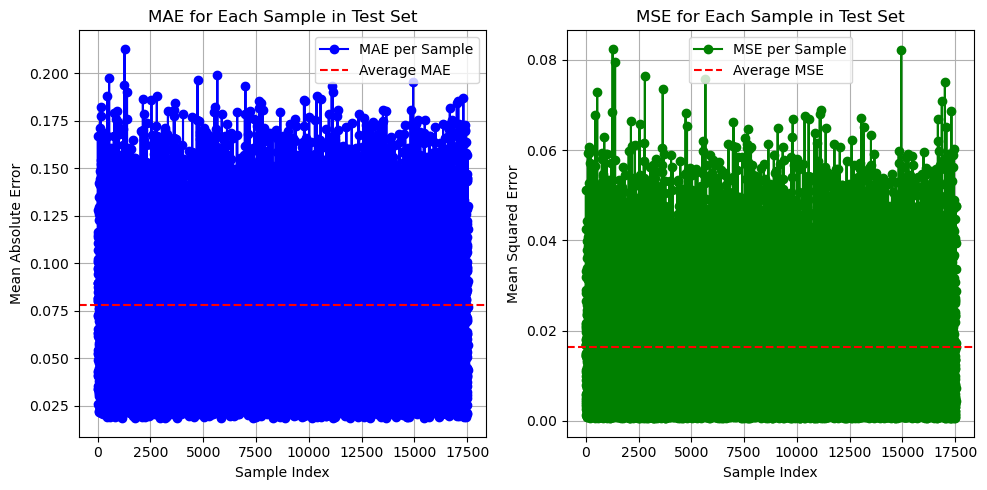

In [27]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    # Calculate MAE and MSE
    mae = mean_absolute_error(X_test_scaled, test_predictions)
    mse = mean_squared_error(X_test_scaled, test_predictions)
    print("Mean Absolute Error:", mae)
    print("Mean Squared Error:", mse)

    # Calculate element-wise MAE and MSE for visualization
    mae_per_sample = np.mean(np.abs(X_test_scaled - test_predictions), axis=1)
    mse_per_sample = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Plotting MAE and MSE
    plt.figure(figsize=(10, 5))

    # Plot MAE
    plt.subplot(1, 2, 1)
    plt.plot(mae_per_sample, marker='o', linestyle='-', color='b', label='MAE per Sample')
    plt.axhline(y=mae, color='r', linestyle='--', label='Average MAE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Absolute Error')
    plt.title('MAE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    # Plot MSE
    plt.subplot(1, 2, 2)
    plt.plot(mse_per_sample, marker='o', linestyle='-', color='g', label='MSE per Sample')
    plt.axhline(y=mse, color='r', linestyle='--', label='Average MSE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Squared Error')
    plt.title('MSE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    # ... [rest of the existing code for the anomaly detection and evaluation metrics]

if __name__ == "__main__":
    main()


10/10 [==============================] - 0s 3ms/step
Mean Absolute Error: 0.05363172209163697
Mean Squared Error: 0.009568583457105753


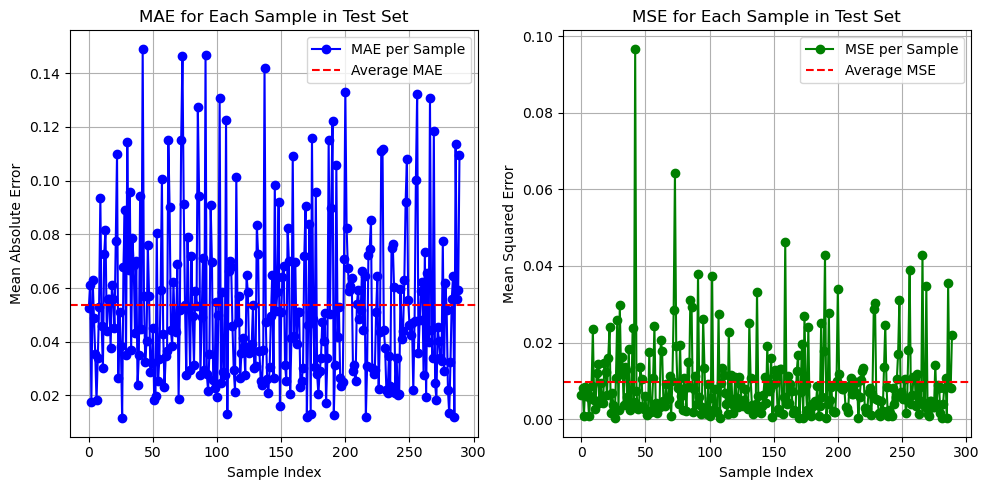

In [28]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    # Calculate MAE and MSE
    mae = mean_absolute_error(X_test_scaled, test_predictions)
    mse = mean_squared_error(X_test_scaled, test_predictions)
    print("Mean Absolute Error:", mae)
    print("Mean Squared Error:", mse)

    # Calculate element-wise MAE and MSE for visualization
    mae_per_sample = np.mean(np.abs(X_test_scaled - test_predictions), axis=1)
    mse_per_sample = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Plotting MAE and MSE
    plt.figure(figsize=(10, 5))

    # Plot MAE
    plt.subplot(1, 2, 1)
    plt.plot(mae_per_sample, marker='o', linestyle='-', color='b', label='MAE per Sample')
    plt.axhline(y=mae, color='r', linestyle='--', label='Average MAE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Absolute Error')
    plt.title('MAE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    # Plot MSE
    plt.subplot(1, 2, 2)
    plt.plot(mse_per_sample, marker='o', linestyle='-', color='g', label='MSE per Sample')
    plt.axhline(y=mse, color='r', linestyle='--', label='Average MSE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Squared Error')
    plt.title('MSE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    # ... [rest of the existing code for the anomaly detection and evaluation metrics]

if __name__ == "__main__":
    main()


548/548 [==============================] - 1s 2ms/step
Mean Absolute Error: 0.04543680857320548
Mean Squared Error: 0.006299176298290147


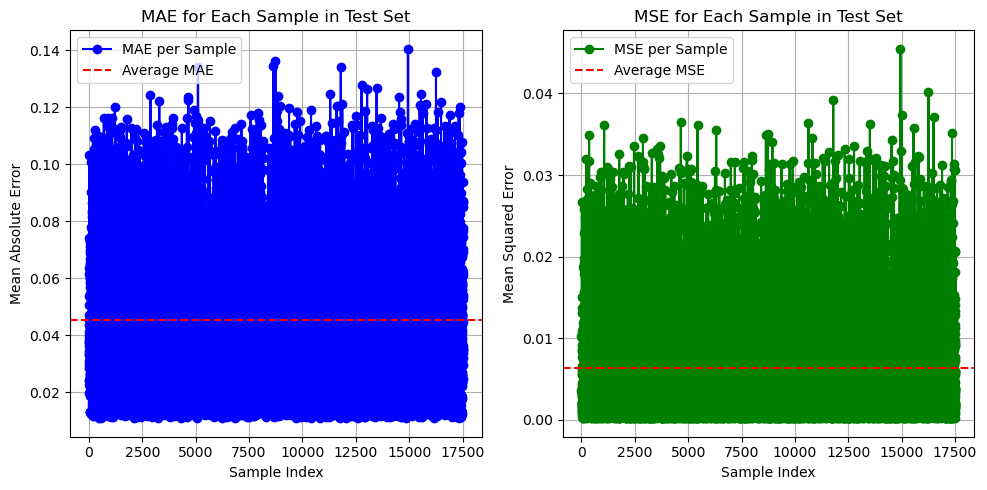

In [29]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_preprocess_data(train_path, test_path):
    # Load train and test data
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)

    # Drop the last column to extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

def main():
    # Load data paths
    data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
    data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

    if not os.path.exists(data_path_train) or not os.path.exists(data_path_test):
        print("Data files not found.")
        return

    X_train, y_train, X_test, y_test = load_and_preprocess_data(data_path_train, data_path_test)
    X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

    # Load the trained autoencoder model
    model_path = "trained_autoencoder_model.h5"
    if not os.path.exists(model_path):
        print("Model file not found.")
        return

    autoencoder = load_model(model_path)
    
    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_predictions = np.squeeze(test_predictions)  # Adjust the shape of test_predictions

    # Ensure the shapes match after squeezing
    if test_predictions.shape != X_test_scaled.shape:
        print("Error: Mismatch in shape between predictions and test data")
        return

    # Calculate MAE and MSE
    mae = mean_absolute_error(X_test_scaled, test_predictions)
    mse = mean_squared_error(X_test_scaled, test_predictions)
    print("Mean Absolute Error:", mae)
    print("Mean Squared Error:", mse)

    # Calculate element-wise MAE and MSE for visualization
    mae_per_sample = np.mean(np.abs(X_test_scaled - test_predictions), axis=1)
    mse_per_sample = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Plotting MAE and MSE
    plt.figure(figsize=(10, 5))

    # Plot MAE
    plt.subplot(1, 2, 1)
    plt.plot(mae_per_sample, marker='o', linestyle='-', color='b', label='MAE per Sample')
    plt.axhline(y=mae, color='r', linestyle='--', label='Average MAE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Absolute Error')
    plt.title('MAE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    # Plot MSE
    plt.subplot(1, 2, 2)
    plt.plot(mse_per_sample, marker='o', linestyle='-', color='g', label='MSE per Sample')
    plt.axhline(y=mse, color='r', linestyle='--', label='Average MSE')
    plt.xlabel('Sample Index')
    plt.ylabel('Mean Squared Error')
    plt.title('MSE for Each Sample in Test Set')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    # ... [rest of the existing code for the anomaly detection and evaluation metrics]

if __name__ == "__main__":
    main()
